In [14]:
import nibabel as nib
import numpy as np
from skimage.morphology import skeletonize
import matplotlib.pyplot as plt
import torch


Load the mask

In [2]:
from google.colab import drive
drive.mount('/content/drive')
mask_path = '/content/drive/MyDrive/CSE291G/topcow_ct_001.nii'
target_path = '/content/drive/MyDrive/CSE291G/'
mask_obj = nib.load(mask_path)
mask_data = mask_obj.get_fdata().astype(np.int16)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
print(mask_data.shape)
print(mask_obj.header.get_zooms())

(284, 327, 243)
(np.float32(0.507813), np.float32(0.507813), np.float32(0.625))


Hemispheric Isolation (The "Stroke" Setup)
To prevent the registration from using the affected side, we split the volume. Typically, the Z-axis is the sagittal plane in these datasets.

In [3]:
def isolate_healthy_hemisphere(mask_data, keep_side='right'):
    """
    Zeros out one half of the brain. 
    Assumes standard orientation where X-axis is Left-Right.
    """
    # Create a copy to avoid mutating original data
    output_mask = mask_data.copy()
    mid_point = mask_data.shape[0] // 2
    
    if keep_side.lower() == 'right':
        # Zero out the Left side (usually higher X indices in many NIfTI headers)
        output_mask[mid_point:, :, :] = 0
    else:
        # Zero out the Right side
        output_mask[:mid_point, :, :] = 0
        
    return output_mask

# Apply to your binary mask for the Q2 and Q3 experiments
healthy_base = isolate_healthy_hemisphere(mask_data, keep_side='right')

Step 1.1: CTA noise

In [4]:

def apply_3d_noise(mask, noise_level=0.1):
    # Convert mask to float
    noisy_mask = mask.astype(np.float32)
    # Add Gaussian noise
    noise = np.random.normal(0, noise_level, mask.shape)
    noisy_mask += noise
    
    # Clip to keep it physically plausible
    return np.clip(noisy_mask, 0, 1)

# Apply this BEFORE creating the DiffDRR projector
q1_gaussian_noised = apply_3d_noise(healthy_base, noise_level=0.2)

Question 2: Preparing the Perturbation Tensors
For Question 2 (Volume Loss), you need a function to randomly "zero out" voxels in the healthy mask.


In [5]:
def simulate_volume_loss(mask, percentage):
    """Randomly zeros out a percentage of vessel voxels."""
    vessel_indices = np.argwhere(mask > 0)
    num_to_zero = int(len(vessel_indices) * (percentage / 100.0))
    
    # Shuffle indices and pick the first N
    np.random.shuffle(vessel_indices)
    zero_coords = vessel_indices[:num_to_zero]
    
    perturbed_mask = mask.copy()
    for coord in zero_coords:
        perturbed_mask[tuple(coord)] = 0
        
    return perturbed_mask

q2_vl_0 = simulate_volume_loss(healthy_base, 0)
q2_vl_10 = simulate_volume_loss(healthy_base, 10)
q2_vl_25 = simulate_volume_loss(healthy_base, 25)
q2_vl_50 = simulate_volume_loss(healthy_base, 50)
q2_vl_100 = simulate_volume_loss(healthy_base, 100)

Question 3: Creating the Perturbation Tensors (Simulation Prep)
To prepare for Question 3, you will generate the "Occlusion Variants" by suppressing one category at a time from the healthy hemisphere.

In [ ]:
PROXIMAL_IDS = [
    1,          # Basilar artery (BA)
    4, 6,       # Right/Left Internal carotid artery (ICA)
    23, 24      # Right/Left Vertebral artery (VA)
]

MEDIUM_IDS = [
    2, 3,       # Right/Left P1 and P2 (PCA)
    5, 7,       # Right/Left M1 (MCA)
    11, 12, 15, # Right/Left/3rd A1 and A2 (ACA)
    8, 9, 10    # Pcom and Acom (Communicating arteries)
]

DISTAL_IDS = [
    13, 14, 16, # Right/Left/3rd A3 (ACA)
    17, 18,     # Right M2/M3 (MCA)
    19, 20,     # Left M2/M3 (MCA)
    21, 22      # Right/Left P3 and P4 (PCA)
]

def generate_occlusion_variant(healthy_mask, category_ids):
    """
    Creates a mask where a specific category of vessels is removed (zeroed out).
    """
    variant_mask = healthy_mask.copy()
    # For every label in the category, find those voxels and set to 0
    for label_id in category_ids:
        variant_mask[variant_mask == label_id] = 0
    return variant_mask


# 2. Create the three experimental variants for Question 3
q3_proximal_occluded = generate_occlusion_variant(healthy_base, PROXIMAL_IDS)
q3_medium_occluded   = generate_occlusion_variant(healthy_base, MEDIUM_IDS)
q3_distal_occluded   = generate_occlusion_variant(healthy_base, DISTAL_IDS)


In [7]:

def save_nifti(data, affine, filename):
    img = nib.Nifti1Image(data.astype(np.float32), affine)
    nib.save(img, filename)

save_nifti(healthy_base, mask_obj.affine, target_path+'healthy_base.nii.gz')

save_nifti(q1_gaussian_noised, mask_obj.affine, target_path+'q1_gaussian_noised.nii.gz')


save_nifti(q2_vl_10, mask_obj.affine, target_path+'q2_vl_10.nii.gz')
save_nifti(q2_vl_25, mask_obj.affine, target_path+'q2_vl_25.nii.gz')
save_nifti(q2_vl_50, mask_obj.affine, target_path+'q2_vl_50.nii.gz')

save_nifti(q3_proximal_occluded, mask_obj.affine, target_path+'q3_proximal_occluded.nii.gz')
save_nifti(q3_medium_occluded, mask_obj.affine, target_path+'q3_medium_occluded.nii.gz')
save_nifti(q3_distal_occluded, mask_obj.affine, target_path+'q3_distal_occluded.nii.gz')

get CTA Before DiffDRR

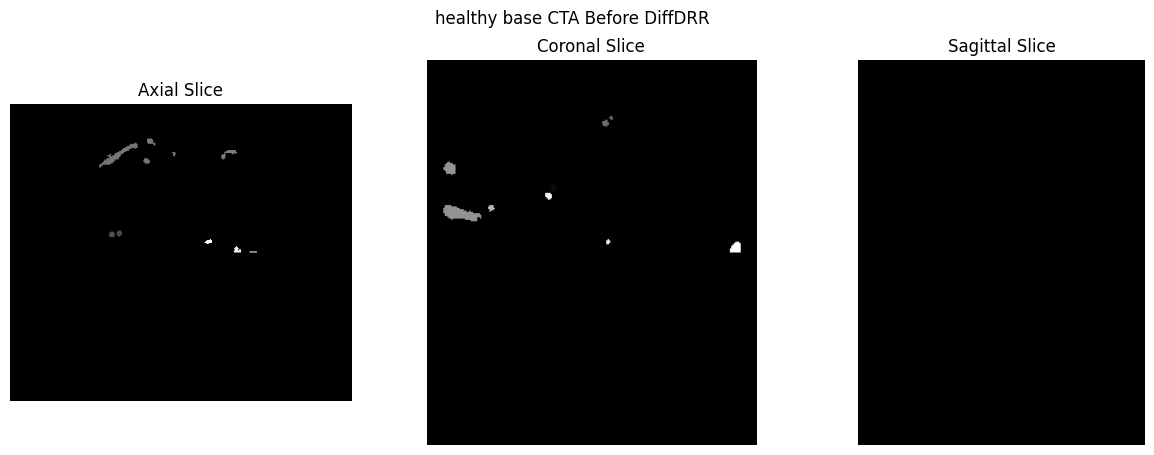

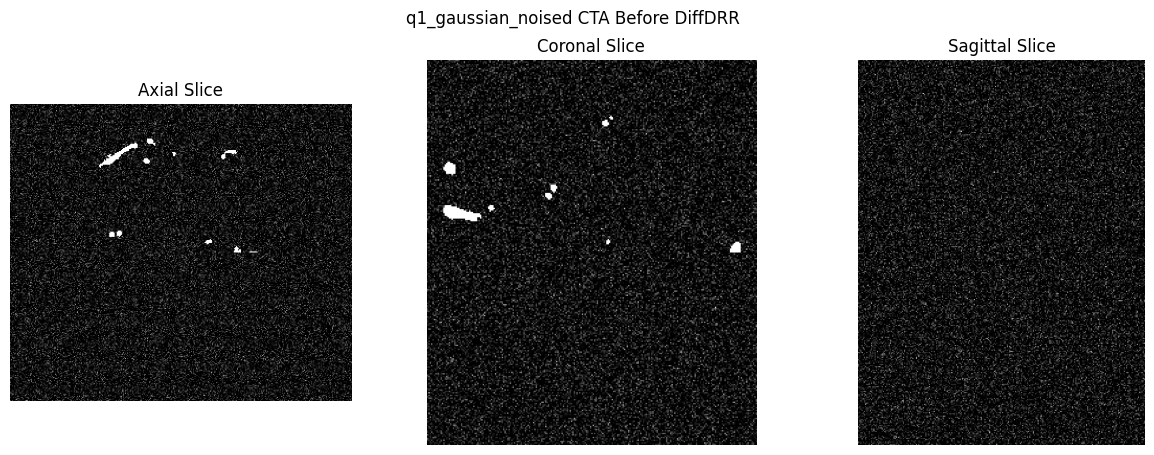

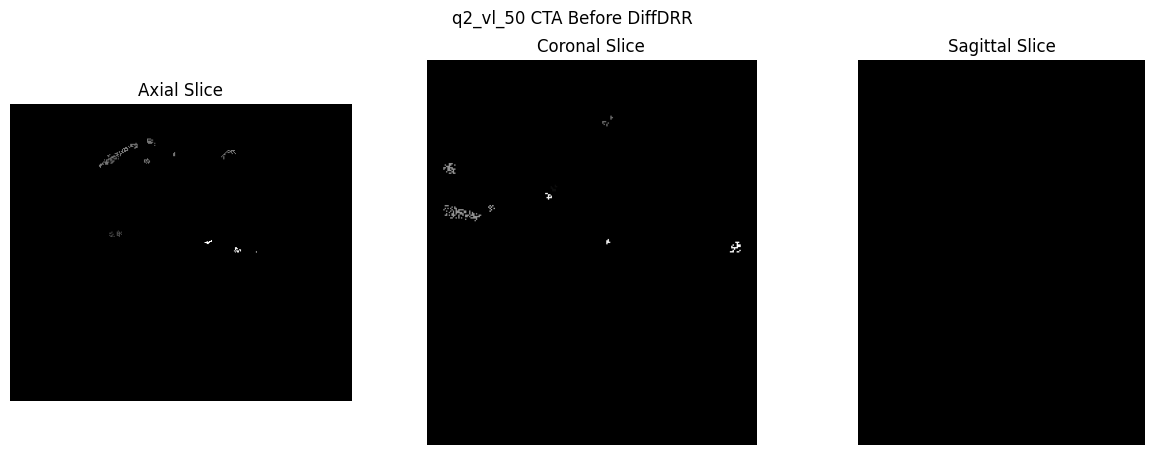

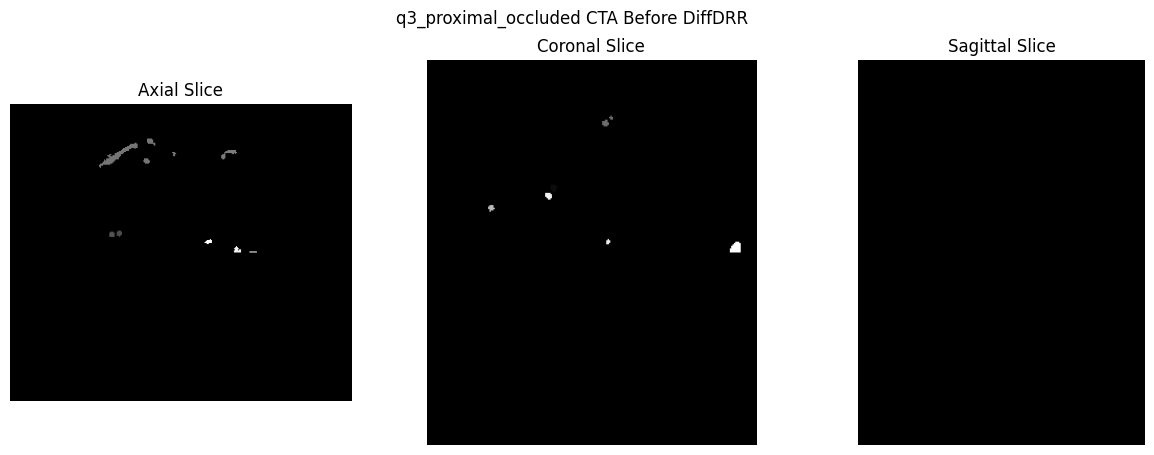

In [19]:
# Get middle slice indices
def get_CTA_Before_DiffDRR(data,name):
    z_mid = data.shape[2] // 2
    y_mid = data.shape[1] // 2
    x_mid = data.shape[0] // 2

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Axial (XY)
    axes[0].imshow(data[:, :, z_mid], cmap='gray')
    axes[0].set_title("Axial Slice")

    # Coronal (XZ)
    axes[1].imshow(data[:, y_mid, :], cmap='gray')
    axes[1].set_title("Coronal Slice")

    # Sagittal (YZ)
    axes[2].imshow(data[x_mid, :, :], cmap='gray')
    axes[2].set_title("Sagittal Slice")

    for ax in axes:
        ax.axis("off")

    plt.suptitle(f"{name} CTA Before DiffDRR")
    plt.show()

get_CTA_Before_DiffDRR(healthy_base,"healthy base")
get_CTA_Before_DiffDRR(q1_gaussian_noised,"q1_gaussian_noised")
get_CTA_Before_DiffDRR(q2_vl_50,"q2_vl_50")
get_CTA_Before_DiffDRR(q3_proximal_occluded,"q3_proximal_occluded")

Get DSA after DiffDRR

In [17]:
!pip install diffdrr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.3/53.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.8/34.8 MB 3.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 83.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 14.6 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.6/145.6 MB 7.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 67.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.2/166.2 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.1/245.1 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.9 MB/s eta 0:00:00
   ━━━

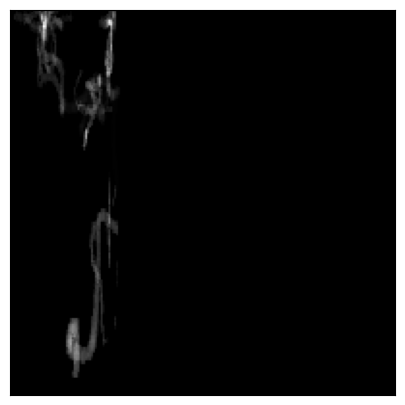

In [18]:
from diffdrr.drr import DRR
from diffdrr.data import load_example_ct
from diffdrr.visualization import plot_drr

subject = load_example_ct()
vessel_tensor = torch.from_numpy(healthy_base).float().unsqueeze(0)
subject.density.set_data(vessel_tensor)

# Initialize the DRR module for generating synthetic X-rays
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
drr = DRR(
    subject,     # An object storing the CT volume, origin, and voxel spacing
    sdd=1020.0,  # Source-to-detector distance (i.e., focal length)
    height=200,  # Image height (if width is not provided, the generated DRR is square)
    delx=2.0,    # Pixel spacing (in mm)
).to(device)

# Set the camera pose with rotations (yaw, pitch, roll) and translations (x, y, z)
rotations = torch.tensor([[0.0, 0.0, 0.0]], device=device)
translations = torch.tensor([[0.0, 850.0, 0.0]], device=device)

# 📸 Also note that DiffDRR can take many representations of SO(3) 📸
# For example, quaternions, rotation matrix, axis-angle, etc...
img = drr(rotations, translations, parameterization="euler_angles", convention="ZXY")
plot_drr(img, ticks=False)
plt.show()